# Data

data from "https://www.kaggle.com/datasets/hafidzunalimaljazari/dataset-penjualan-dummy"

In [1]:
!pip install opendatasets

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od
import matplotlib.ticker as mtick

In [2]:
dataset_url = "https://www.kaggle.com/datasets/hafidzunalimaljazari/dataset-penjualan-dummy"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: akialgrowto
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/hafidzunalimaljazari/dataset-penjualan-dummy


100%|██████████| 3.16M/3.16M [00:00<00:00, 203MB/s]

📝 Penjelasan Setiap Kolom
Transaction_ID: Kode pengenal unik yang diberikan untuk setiap transaksi penjualan individual.

Date: Tanggal spesifik (hari, bulan, tahun) di mana transaksi penjualan tercatat. Digunakan untuk analisis tren temporal.

Product_Name: Nama lengkap atau merek dagang dari item barang yang terjual dalam transaksi.

Category: Pengelompokan produk ke dalam kategori yang lebih luas (misalnya, Groceries, Instant Noodles, Drinks).

Units_Sold: Kuantitas (jumlah unit) dari produk tersebut yang dibeli oleh pelanggan dalam satu transaksi.

Unit_Price: Harga jual per satu unit produk pada saat transaksi terjadi.

Revenue: Total pendapatan moneter yang dihasilkan dari penjualan item tersebut (dihitung dari Units_Sold dikali Unit_Price).

Store_Location: Kota spesifik tempat toko ASR Ritel yang melakukan penjualan berada (misalnya, Depok, Surabaya, Tasikmalaya).

Payment_Method: Cara pembayaran yang digunakan oleh pelanggan untuk menyelesaikan transaksi.

Province: Wilayah administratif tingkat pertama (provinsi) tempat toko berlokasi (meliputi Banten, DI Yogyakarta, DKI Jakarta, Jawa Barat, Jawa Tengah, dan Jawa Timur).

Unit cost: biaya yang dibutuhkan untuk membuat atau menyediakan satu unit barang

In [6]:
df = pd.read_csv('/content/dataset-penjualan-dummy/DatasetPenjualanToko.csv', sep=';')

#5 data teratas
df.head()

,Transaction_ID,Date,Product_Name,Category,Units_Sold,Unit_Price,Revenue,Store_Location,Payment_Method,Province,Unit Cost,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,JATNG_PURJO_00001,01/01/2023,Nabati Wafer,Snacks,7,5.0,35.000,Purworejo,Card,Jawa Tengah,4.400,NaN,NaN,NaN,NaN,NaN
1,JABAR_SUMNG_00002,01/01/2023,Sedaap Soto,Instant Noodles,16,3.8,60.800,Sumedang,Cash,Jawa Barat,3.420,NaN,NaN,NaN,NaN,NaN
2,JABAR_BANAT_00003,01/01/2023,Sari Roti Tawar,Snacks,2,12.0,24.000,Bandung Barat,Cash,Jawa Barat,10.560,NaN,NaN,NaN,NaN,NaN
3,JABAR_SUMNG_00004,01/01/2023,Pantene Shampoo 1L,Personal Care,6,45.0,270.000,Sumedang,Cash,Jawa Barat,33.750,NaN,NaN,NaN,NaN,NaN
4,JATIM_MADUN_00005,01/01/2023,Tolako Minuman Herbal,Health,16,8.5,136.000,Madiun,Cash,Jawa Timur,6.375,NaN,NaN,NaN,NaN,NaN


In [7]:
df.tail()

,Transaction_ID,Date,Product_Name,Category,Units_Sold,Unit_Price,Revenue,Store_Location,Payment_Method,Province,Unit Cost,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
199995,JATNG_BANAS_199996,31/12/2024,Aqua 600ml,Drinks,30,4.0,120.000,Banyumas,Cash,Jawa Tengah,3.400,NaN,NaN,NaN,NaN,NaN
199996,JABAR_BANNG_199997,31/12/2024,Tolak Angin,Health,15,7.0,105.000,Bandung,Cash,Jawa Barat,5.250,NaN,NaN,NaN,NaN,NaN
199997,JATIM_MAGAN_199998,31/12/2024,Indomilk UHT 1L,Drinks,57,15.0,855.000,Magetan,Card,Jawa Timur,13.200,NaN,NaN,NaN,NaN,NaN
199998,JATIM_MOJTO_199999,31/12/2024,Tolako Minuman Herbal,Health,6,8.5,51.000,Mojokerto,Cash,Jawa Timur,6.375,NaN,NaN,NaN,NaN,NaN
199999,JATNG_SUKJO_200000,31/12/2024,Lifebuoy Body Wash,Personal Care,33,25.0,825.000,Sukoharjo,Cash,Jawa Tengah,18.750,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns

Index(['Transaction_ID', 'Date', 'Product_Name', 'Category', 'Units_Sold',
       'Unit_Price', 'Revenue', 'Store_Location', 'Payment_Method', 'Province',
       'Unit Cost', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='object')

In [9]:
print('Number of Rows: {}'.format(df.shape[0]))
print('Number of Cols: {}'.format(df.shape[1]))

Number of Rows: 200000
Number of Cols: 16


# Data Preprocessing

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Transaction_ID  200000 non-null  object 
 1   Date            200000 non-null  object 
 2   Product_Name    200000 non-null  object 
 3   Category        200000 non-null  object 
 4   Units_Sold      200000 non-null  int64  
 5   Unit_Price      200000 non-null  float64
 6   Revenue         200000 non-null  object 
 7   Store_Location  200000 non-null  object 
 8   Payment_Method  200000 non-null  object 
 9   Province        200000 non-null  object 
 10  Unit Cost       200000 non-null  float64
 11  Unnamed: 11     0 non-null       float64
 12  Unnamed: 12     0 non-null       float64
 13  Unnamed: 13     0 non-null       float64
 14  Unnamed: 14     0 non-null       float64
 15  Unnamed: 15     0 non-null       float64
dtypes: float64(7), int64(1), object(8)
memory usage: 24.4+ M

In [11]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
199995,False
199996,False
199997,False
199998,False


In [13]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Product_Name,0
Category,0
Units_Sold,0
Unit_Price,0
Revenue,0
Store_Location,0
Payment_Method,0
Province,0


In [14]:
df = df.drop(columns=['Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15'])

In [15]:
df.columns

Index(['Transaction_ID', 'Date', 'Product_Name', 'Category', 'Units_Sold',
       'Unit_Price', 'Revenue', 'Store_Location', 'Payment_Method', 'Province',
       'Unit Cost'],
      dtype='object')

In [40]:
df['Revenue'].dtype

dtype('O')

In [42]:
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

print(df['Revenue'].dtype)

float64


In [18]:
df['Date'].dtype

dtype('O')

In [21]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [30]:
df['year'] = pd.DatetimeIndex(df['Date']).year

df['year'].value_counts()

,count
year,
2023,100131
2024,99869


In [31]:
df['month'] = pd.DatetimeIndex(df['Date']).month

df['month'].value_counts()

,count
month,
1,17154
5,17126
7,17019
10,16950
3,16915
12,16904
8,16844
9,16490
11,16448


In [22]:
df.head()

,Transaction_ID,Date,Product_Name,Category,Units_Sold,Unit_Price,Revenue,Store_Location,Payment_Method,Province,Unit Cost
0,JATNG_PURJO_00001,2023-01-01,Nabati Wafer,Snacks,7,5.0,35.000,Purworejo,Card,Jawa Tengah,4.400
1,JABAR_SUMNG_00002,2023-01-01,Sedaap Soto,Instant Noodles,16,3.8,60.800,Sumedang,Cash,Jawa Barat,3.420
2,JABAR_BANAT_00003,2023-01-01,Sari Roti Tawar,Snacks,2,12.0,24.000,Bandung Barat,Cash,Jawa Barat,10.560
3,JABAR_SUMNG_00004,2023-01-01,Pantene Shampoo 1L,Personal Care,6,45.0,270.000,Sumedang,Cash,Jawa Barat,33.750
4,JATIM_MADUN_00005,2023-01-01,Tolako Minuman Herbal,Health,16,8.5,136.000,Madiun,Cash,Jawa Timur,6.375


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Transaction_ID  200000 non-null  object        
 1   Date            200000 non-null  datetime64[ns]
 2   Product_Name    200000 non-null  object        
 3   Category        200000 non-null  object        
 4   Units_Sold      200000 non-null  int64         
 5   Unit_Price      200000 non-null  float64       
 6   Revenue         200000 non-null  object        
 7   Store_Location  200000 non-null  object        
 8   Payment_Method  200000 non-null  object        
 9   Province        200000 non-null  object        
 10  Unit Cost       200000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 16.8+ MB


In [25]:
df.describe()

,Date,Units_Sold,Unit_Price,Unit Cost
count,200000,200000.000000,200000.000000,200000.000000
mean,2023-12-31 08:32:38.399999488,14.916030,21.964157,18.643365
min,2023-01-01 00:00:00,1.000000,3.800000,3.400000
25%,2023-07-01 00:00:00,6.000000,7.000000,5.250000
50%,2023-12-31 00:00:00,12.000000,15.000000,11.250000
75%,2024-07-02 00:00:00,18.000000,33.000000,29.040000
max,2024-12-31 00:00:00,60.000000,90.000000,79.200000
std,NaN,12.148888,22.126065,19.402014


In [27]:
df.nunique()

,0
Transaction_ID,200000
Date,731
Product_Name,20
Category,7
Units_Sold,43
Unit_Price,18
Revenue,509
Store_Location,97
Payment_Method,2
Province,6


# Explanatory Data Analysis

In [73]:
df1 = df.copy()

In [74]:
df1.head()

,Transaction_ID,Date,Product_Name,Category,Units_Sold,Unit_Price,Revenue,Store_Location,Payment_Method,Province,Unit Cost,year,month
0,JATNG_PURJO_00001,2023-01-01,Nabati Wafer,Snacks,7,5.0,35.0,Purworejo,Card,Jawa Tengah,4.400,2023,1
1,JABAR_SUMNG_00002,2023-01-01,Sedaap Soto,Instant Noodles,16,3.8,60.8,Sumedang,Cash,Jawa Barat,3.420,2023,1
2,JABAR_BANAT_00003,2023-01-01,Sari Roti Tawar,Snacks,2,12.0,24.0,Bandung Barat,Cash,Jawa Barat,10.560,2023,1
3,JABAR_SUMNG_00004,2023-01-01,Pantene Shampoo 1L,Personal Care,6,45.0,270.0,Sumedang,Cash,Jawa Barat,33.750,2023,1
4,JATIM_MADUN_00005,2023-01-01,Tolako Minuman Herbal,Health,16,8.5,136.0,Madiun,Cash,Jawa Timur,6.375,2023,1


In [75]:
df1.columns

Index(['Transaction_ID', 'Date', 'Product_Name', 'Category', 'Units_Sold',
       'Unit_Price', 'Revenue', 'Store_Location', 'Payment_Method', 'Province',
       'Unit Cost', 'year', 'month'],
      dtype='object')

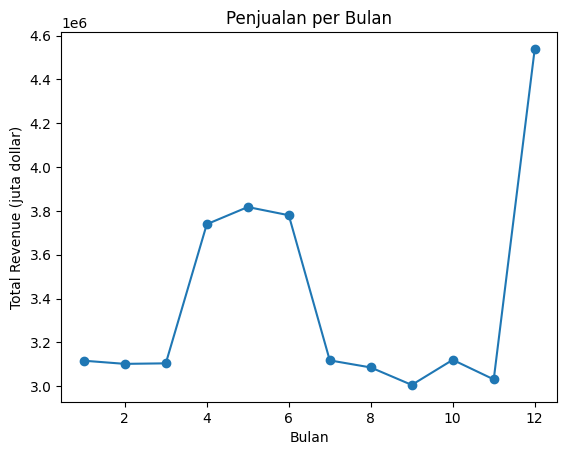

In [77]:
#Total penjualan perbulan

monthly_sales = df.groupby('month')['Revenue'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Penjualan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue (juta dollar)")
plt.show()

In [125]:
def analyze_data(
    df,
    group_by='Product_Name',  # bisa diganti 'Category'
    year=None,
    month=None,
    metric='Units_Sold',      # atau 'count'
    top=True,
    n=10,
    plot=True
):
    data = df.copy()

    # filter tahun
    if year is not None:
        data = data[data['Year'] == year]

    # filter bulan
    if month is not None:
        data = data[data['month'] == month]

    # pilih metric
    if metric == 'Units_Sold':
        result = data.groupby(group_by)['Units_Sold'].sum()
    else:
        result = data[group_by].value_counts()

    # sorting
    result = result.sort_values(ascending=not top).head(n)

    # plot
    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(8,6))
        result.plot(kind='barh')

        if top:
            plt.gca().invert_yaxis()

        for i, v in enumerate(result):
            plt.text(v, i, f"{int(v):,}", va='center')

        title = f"{'Top' if top else 'Bottom'} {group_by}"

        if year:
            title += f" Tahun {year}"
        if month:
            title += f" Bulan {month}"

        plt.title(title)
        plt.xlabel(metric)
        plt.show()

    return result.reset_index()

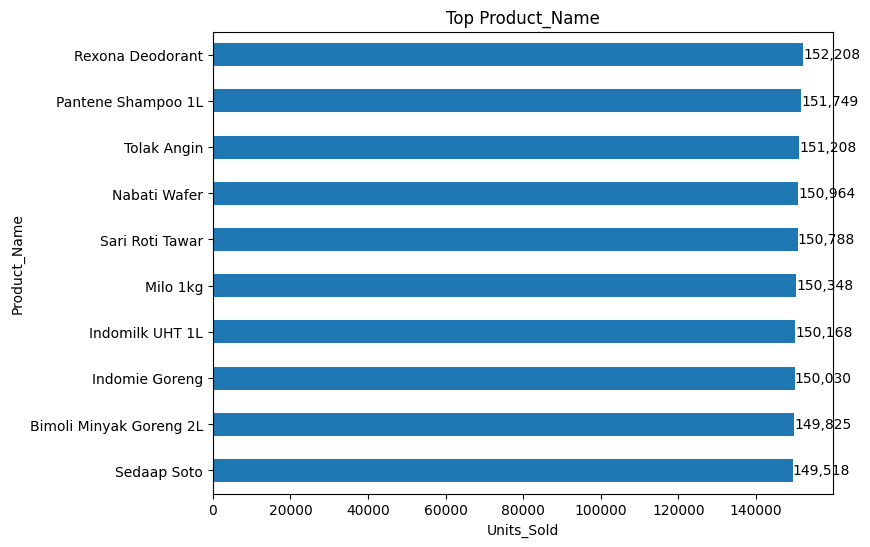

,Product_Name,Units_Sold
0,Rexona Deodorant,152208
1,Pantene Shampoo 1L,151749
2,Tolak Angin,151208
3,Nabati Wafer,150964
4,Sari Roti Tawar,150788
5,Milo 1kg,150348
6,Indomilk UHT 1L,150168
7,Indomie Goreng,150030
8,Bimoli Minyak Goreng 2L,149825
9,Sedaap Soto,149518


In [126]:
#Produk terlaris
analyze_data(df1, group_by='Product_Name')

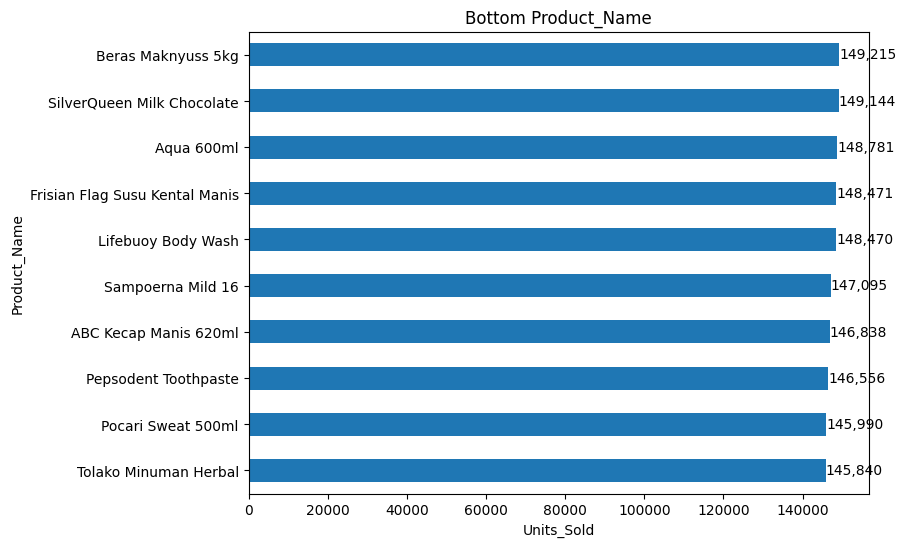

,Product_Name,Units_Sold
0,Tolako Minuman Herbal,145840
1,Pocari Sweat 500ml,145990
2,Pepsodent Toothpaste,146556
3,ABC Kecap Manis 620ml,146838
4,Sampoerna Mild 16,147095
5,Lifebuoy Body Wash,148470
6,Frisian Flag Susu Kental Manis,148471
7,Aqua 600ml,148781
8,SilverQueen Milk Chocolate,149144
9,Beras Maknyuss 5kg,149215


In [127]:
#Produk tidak terlaris
analyze_data(df1, group_by='Product_Name', top=False)

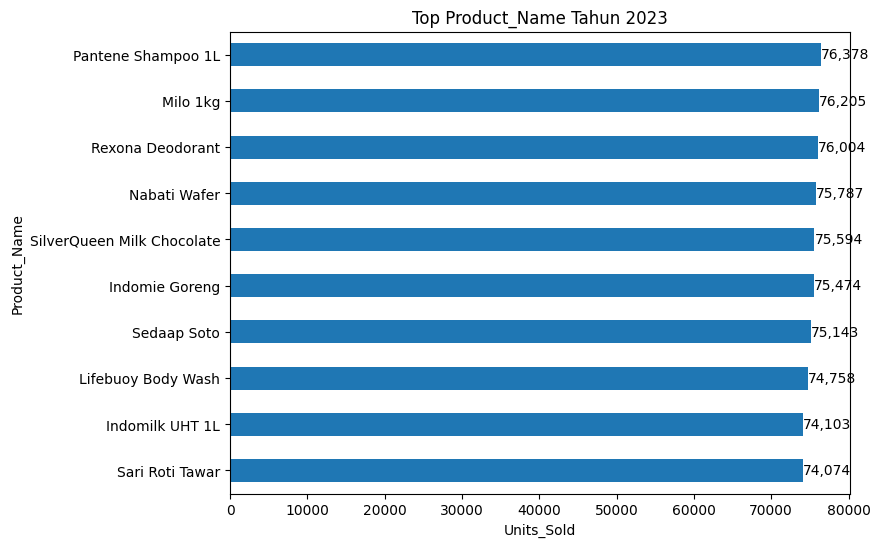

,Product_Name,Units_Sold
0,Pantene Shampoo 1L,76378
1,Milo 1kg,76205
2,Rexona Deodorant,76004
3,Nabati Wafer,75787
4,SilverQueen Milk Chocolate,75594
5,Indomie Goreng,75474
6,Sedaap Soto,75143
7,Lifebuoy Body Wash,74758
8,Indomilk UHT 1L,74103
9,Sari Roti Tawar,74074


In [128]:
#Produk terlaris di tahun 2023
analyze_data(df1, group_by='Product_Name', year=2023)

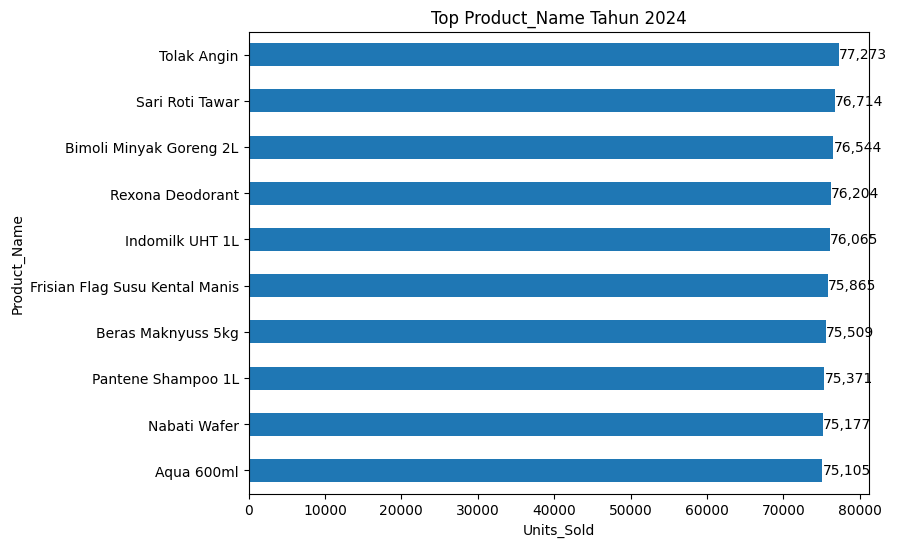

,Product_Name,Units_Sold
0,Tolak Angin,77273
1,Sari Roti Tawar,76714
2,Bimoli Minyak Goreng 2L,76544
3,Rexona Deodorant,76204
4,Indomilk UHT 1L,76065
5,Frisian Flag Susu Kental Manis,75865
6,Beras Maknyuss 5kg,75509
7,Pantene Shampoo 1L,75371
8,Nabati Wafer,75177
9,Aqua 600ml,75105


In [129]:
#Produk terlaris di tahun 2024
analyze_data(df1, group_by='Product_Name', year=2024)

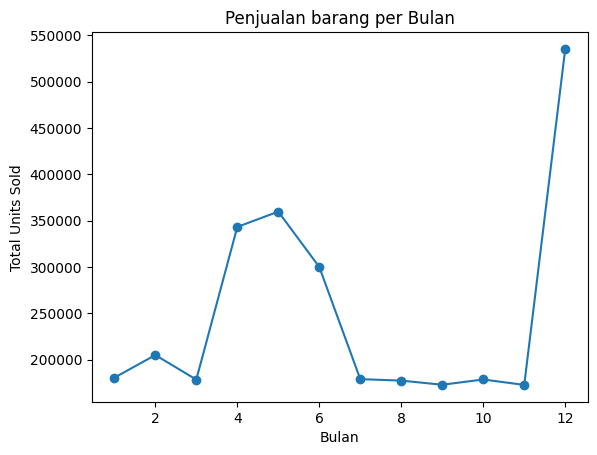

In [103]:
#jumlah penjualan barang perbulan

monthly_sales = df.groupby('month')['Units_Sold'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Penjualan barang per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Units Sold")
plt.show()

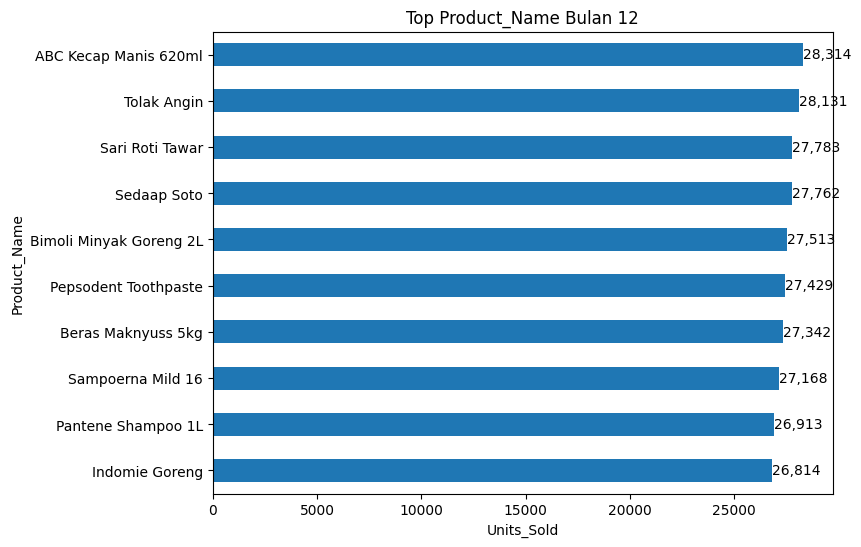

,Product_Name,Units_Sold
0,ABC Kecap Manis 620ml,28314
1,Tolak Angin,28131
2,Sari Roti Tawar,27783
3,Sedaap Soto,27762
4,Bimoli Minyak Goreng 2L,27513
5,Pepsodent Toothpaste,27429
6,Beras Maknyuss 5kg,27342
7,Sampoerna Mild 16,27168
8,Pantene Shampoo 1L,26913
9,Indomie Goreng,26814


In [130]:
#Produk terlaris di bulan Desembar
analyze_data(df1, group_by='Product_Name', month=12)

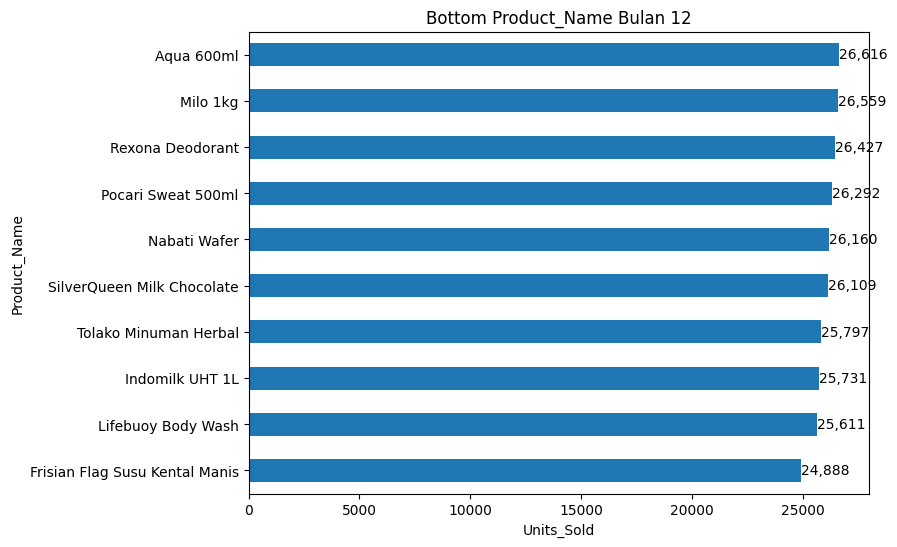

,Product_Name,Units_Sold
0,Frisian Flag Susu Kental Manis,24888
1,Lifebuoy Body Wash,25611
2,Indomilk UHT 1L,25731
3,Tolako Minuman Herbal,25797
4,SilverQueen Milk Chocolate,26109
5,Nabati Wafer,26160
6,Pocari Sweat 500ml,26292
7,Rexona Deodorant,26427
8,Milo 1kg,26559
9,Aqua 600ml,26616


In [131]:
#Tidak terlaris di Desember
analyze_data(df1, group_by='Product_Name', month=12, top=False)

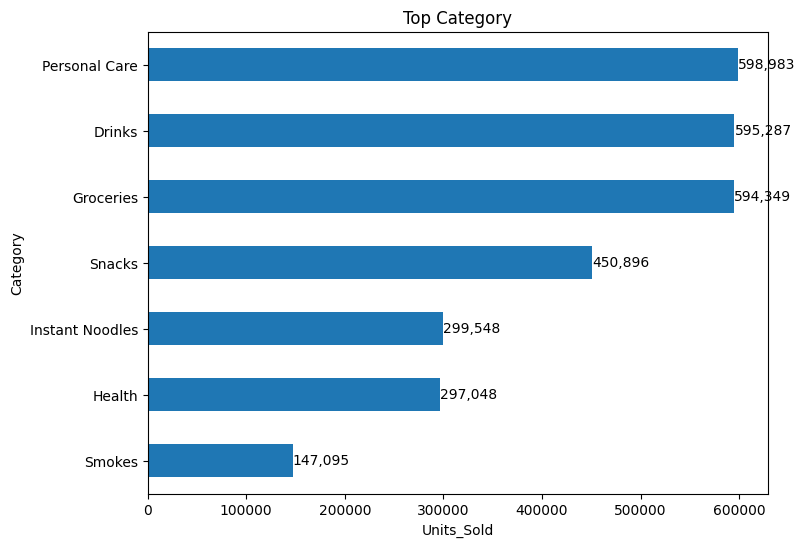

,Category,Units_Sold
0,Personal Care,598983
1,Drinks,595287
2,Groceries,594349
3,Snacks,450896
4,Instant Noodles,299548
5,Health,297048
6,Smokes,147095


In [120]:
#Kategori produk terlaris
analyze_data(df1, group_by='Category')

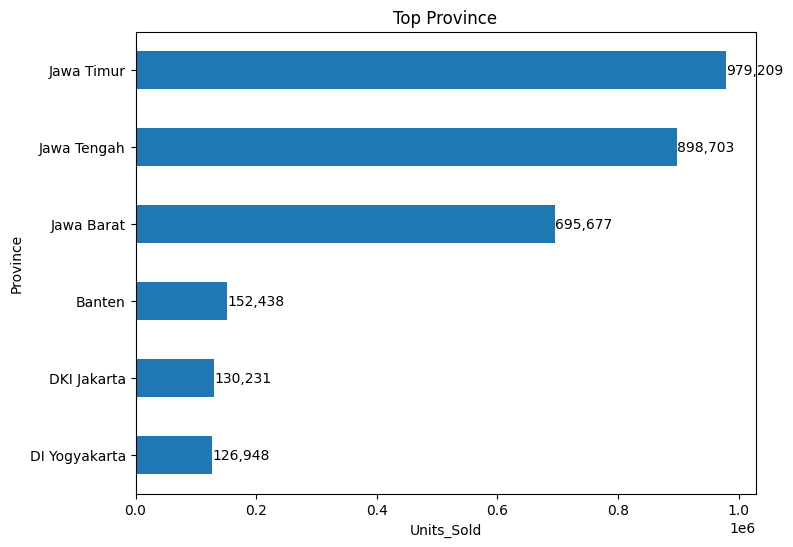

,Province,Units_Sold
0,Jawa Timur,979209
1,Jawa Tengah,898703
2,Jawa Barat,695677
3,Banten,152438
4,DKI Jakarta,130231
5,DI Yogyakarta,126948


In [133]:
#Store provinsi dengan produk paling banyak terjual
analyze_data(df1, group_by='Province')

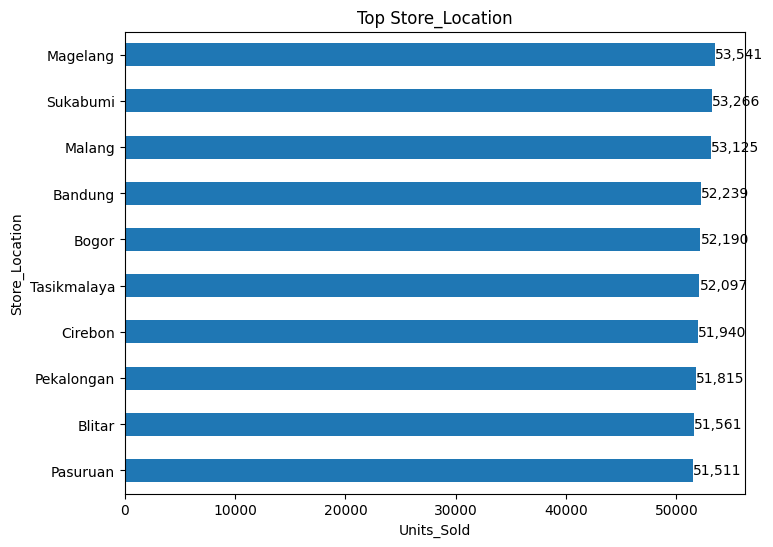

,Store_Location,Units_Sold
0,Magelang,53541
1,Sukabumi,53266
2,Malang,53125
3,Bandung,52239
4,Bogor,52190
5,Tasikmalaya,52097
6,Cirebon,51940
7,Pekalongan,51815
8,Blitar,51561
9,Pasuruan,51511


In [134]:
#kota dengan penjualan produk terbanyak
analyze_data(df1, group_by='Store_Location')

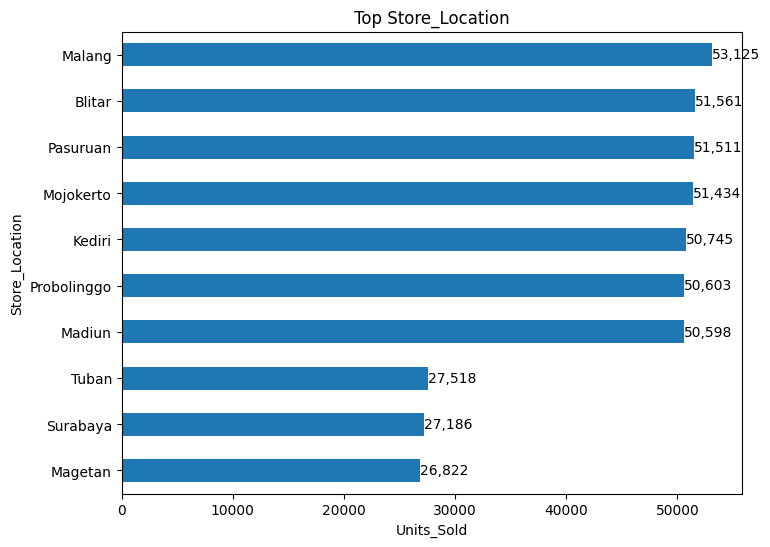

,Store_Location,Units_Sold
0,Malang,53125
1,Blitar,51561
2,Pasuruan,51511
3,Mojokerto,51434
4,Kediri,50745
5,Probolinggo,50603
6,Madiun,50598
7,Tuban,27518
8,Surabaya,27186
9,Magetan,26822


In [136]:
#Provinsi Jawa Timur merupakan provinsi dengan penjualan produk terbanyak
#kita lihat di kota mana saja di provinsi Jawa Timur
df_jatim = df1[df1['Province'] == 'Jawa Timur']

analyze_data(df_jatim, group_by='Store_Location')

## Keuntungan

In [144]:
df1['Margin'] = df1['Revenue'] - df1['Unit Cost']
df1['Profit'] = df1['Margin'] * df1['Units_Sold']

In [145]:
df1.head()

,Transaction_ID,Date,Product_Name,Category,Units_Sold,Unit_Price,Revenue,Store_Location,Payment_Method,Province,Unit Cost,year,month,Year,Profit,Margin
0,JATNG_PURJO_00001,2023-01-01,Nabati Wafer,Snacks,7,5.0,35.0,Purworejo,Card,Jawa Tengah,4.400,2023,1,2023,214.20,30.600
1,JABAR_SUMNG_00002,2023-01-01,Sedaap Soto,Instant Noodles,16,3.8,60.8,Sumedang,Cash,Jawa Barat,3.420,2023,1,2023,918.08,57.380
2,JABAR_BANAT_00003,2023-01-01,Sari Roti Tawar,Snacks,2,12.0,24.0,Bandung Barat,Cash,Jawa Barat,10.560,2023,1,2023,26.88,13.440
3,JABAR_SUMNG_00004,2023-01-01,Pantene Shampoo 1L,Personal Care,6,45.0,270.0,Sumedang,Cash,Jawa Barat,33.750,2023,1,2023,1417.50,236.250
4,JATIM_MADUN_00005,2023-01-01,Tolako Minuman Herbal,Health,16,8.5,136.0,Madiun,Cash,Jawa Timur,6.375,2023,1,2023,2074.00,129.625


                 Product_Name       Profit
0          Pantene Shampoo 1L  54553477.50
1             Indomilk UHT 1L  53202729.90
2     Bimoli Minyak Goreng 2L  53050157.82
3       ABC Kecap Manis 620ml  53004077.64
4        Pepsodent Toothpaste  52472512.50
5            Rexona Deodorant  52317075.00
6          Lifebuoy Body Wash  49556181.25
7           Sampoerna Mild 16  49039626.24
8             Sari Roti Tawar  43782930.72
9  SilverQueen Milk Chocolate  43650237.36


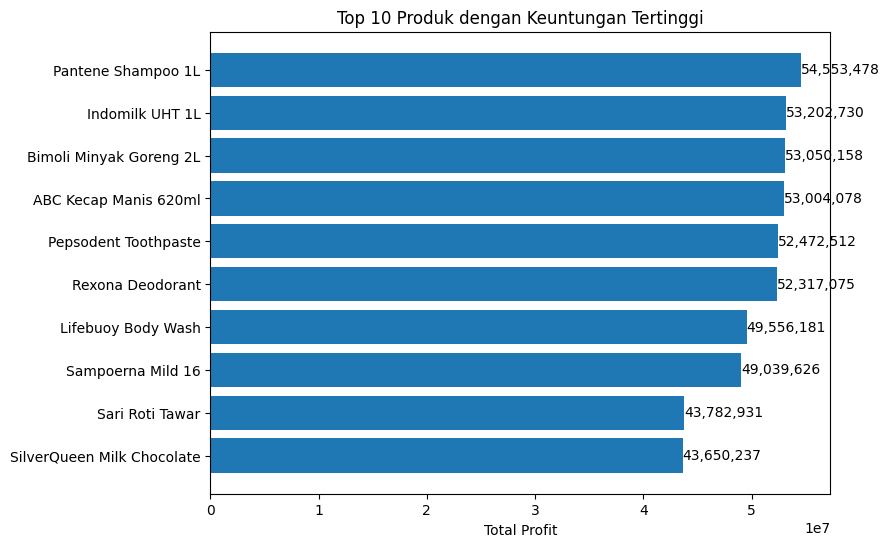

In [149]:
top_profit_product = df1.groupby('Product_Name')['Profit'] \
                        .sum() \
                        .sort_values(ascending=False) \
                        .head(10) \
                        .reset_index()

plt.figure(figsize=(8,6))

plt.barh(top_profit_product['Product_Name'], top_profit_product['Profit'])

plt.gca().invert_yaxis()

# label angka
for i, v in enumerate(top_profit_product['Profit']):
    plt.text(v, i, f"{v:,.0f}", va='center')

plt.title("Top 10 Produk dengan Keuntungan Tertinggi")
plt.xlabel("Total Profit")

print(top_profit_product)
plt.show()

In [150]:
df1.groupby('Product_Name').agg({
    'Units_Sold': 'sum',
    'Margin': 'mean',
    'Profit': 'sum'
}).sort_values('Profit', ascending=False).head(10)

,Units_Sold,Margin,Profit
Product_Name,,,
Pantene Shampoo 1L,151749,448.176525,54553477.50
Indomilk UHT 1L,150168,208.885596,53202729.90
Bimoli Minyak Goreng 2L,149825,358.424207,53050157.82
ABC Kecap Manis 620ml,146838,238.047187,53004077.64
Pepsodent Toothpaste,146556,211.292068,52472512.50
Rexona Deodorant,152208,255.432086,52317075.00
Lifebuoy Body Wash,148470,293.213811,49556181.25
Sampoerna Mild 16,147095,385.728099,49039626.24
Sari Roti Tawar,150788,170.377218,43782930.72
